# SHOAIB ALI KORI | 24I-2605 | BDS-5A | DAV LAB 04

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

### Task 1 — Univariate Analysis of Sales

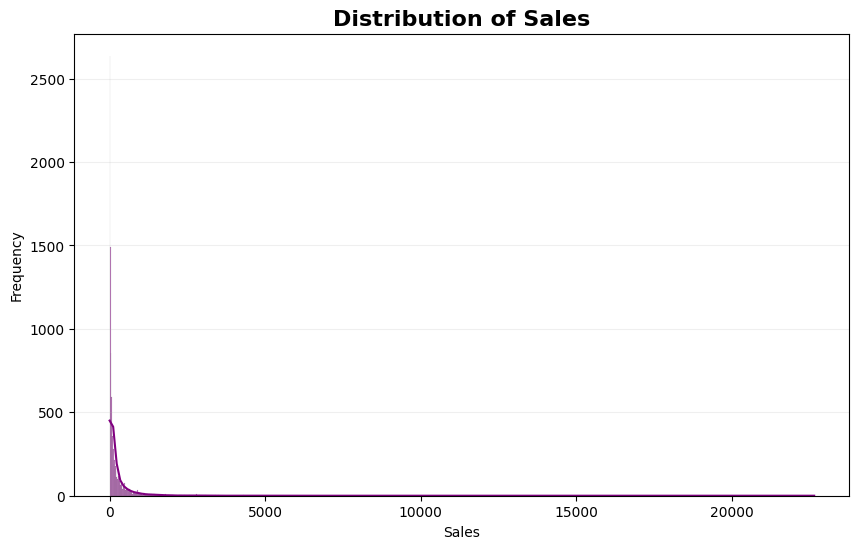

Skewness: 12.97
Mean: 229.86
Median: 54.49


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Sales",
    kde=True,
    color="purple"
)

plt.title("Distribution of Sales", fontsize=16, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.2)

plt.show()

skewness = df["Sales"].skew()
mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()

print("Skewness:", round(skewness, 2))
print("Mean:", round(mean_sales, 2))
print("Median:", round(median_sales, 2))

The Sales distribution is strongly right-skewed, with a skewness of approximately 12.97. The mean sales (229.86) is much higher than the median sales (54.49), indicating the presence of some very large sales values. Therefore, the median may be a better representation of a typical sale than the mean.

### Task 2 — Categorical × Numerical

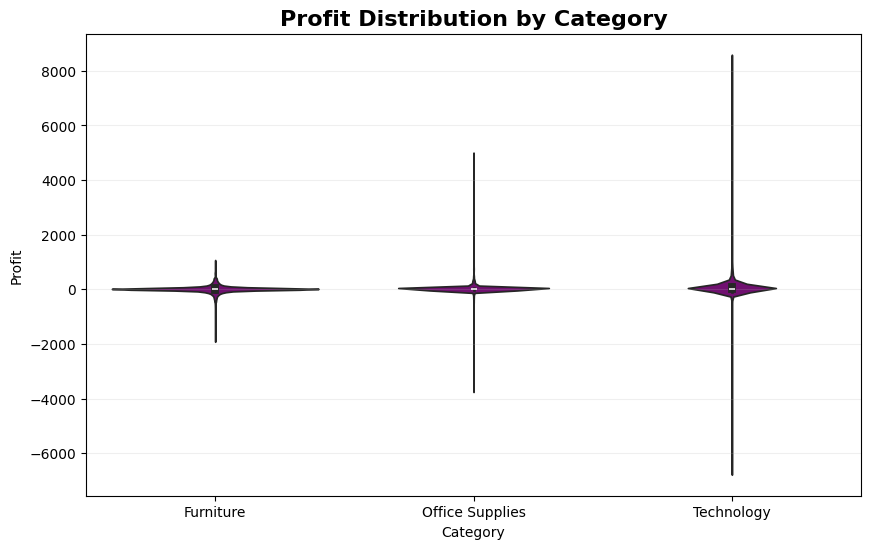

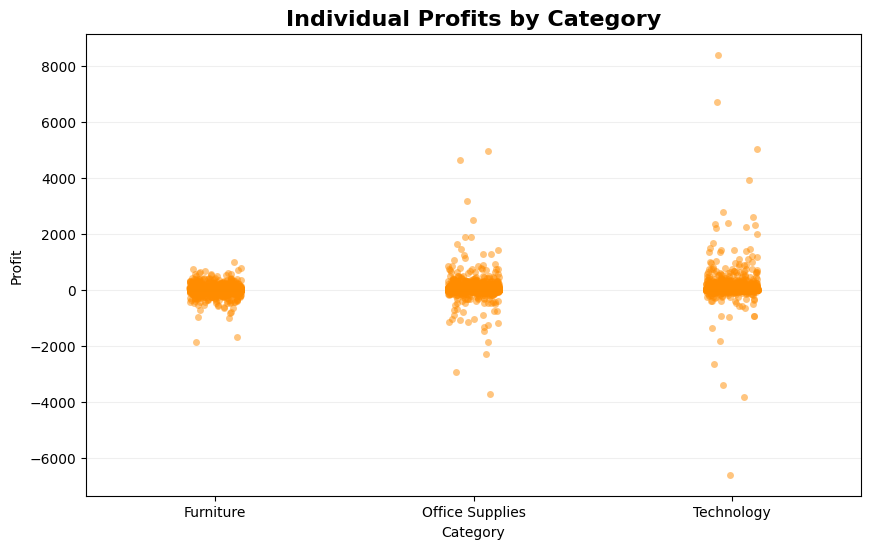

In [5]:
# Violin Plot

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Category",
    y="Profit",
    color="purple"
)

plt.title("Profit Distribution by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.grid(axis="y", alpha=0.2)

plt.show()


# Strip Plot

plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df,
    x="Category",
    y="Profit",
    jitter=True,
    color="darkorange",
    alpha=0.5
)

plt.title("Individual Profits by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.grid(axis="y", alpha=0.2)

plt.show()

Because the violin plot shows the density and shape of the distribution, so it is best than the strip plot.

### Task 3 — Multivariate Encoding

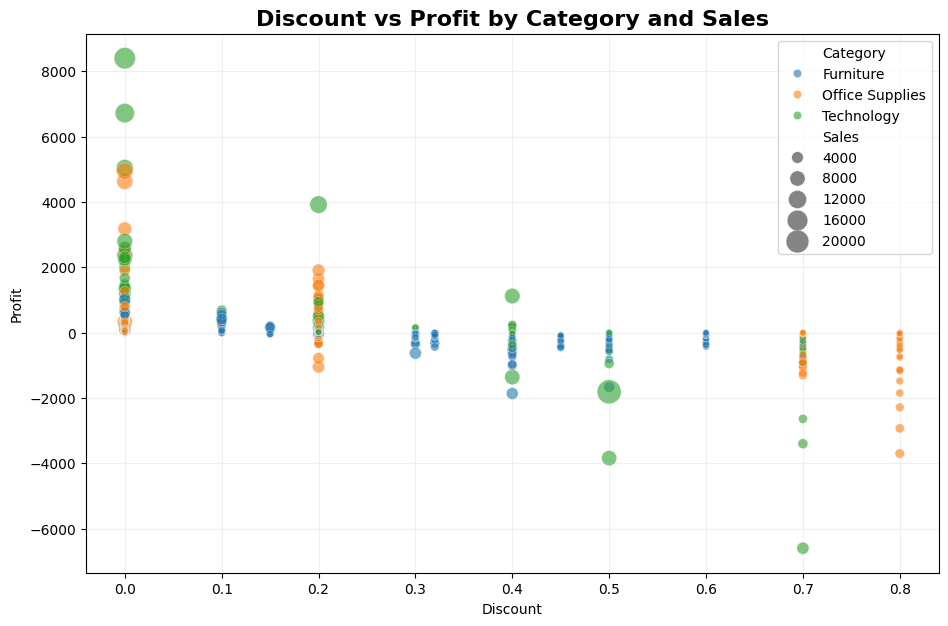

In [6]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    size="Sales",
    sizes=(20, 300),
    alpha=0.6
)

plt.title("Discount vs Profit by Category and Sales",
          fontsize=16, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(alpha=0.2)

plt.show()

The plot shows that higher discounts are generally associated with lower profits, and the larger points show that this effect also occurs for some high-sales orders. The category colors reveal that this pattern varies across categories.

### Task 4 — Correlation

Pearson Correlation Matrix:
             Row ID  Postal Code  Sales  Quantity  Discount  Profit
Row ID         1.00         0.01  -0.00     -0.00      0.01    0.01
Postal Code    0.01         1.00  -0.02      0.01      0.06   -0.03
Sales         -0.00        -0.02   1.00      0.20     -0.03    0.48
Quantity      -0.00         0.01   0.20      1.00      0.01    0.07
Discount       0.01         0.06  -0.03      0.01      1.00   -0.22
Profit         0.01        -0.03   0.48      0.07     -0.22    1.00

Spearman Correlation Matrix:
             Row ID  Postal Code  Sales  Quantity  Discount  Profit
Row ID         1.00         0.01  -0.00     -0.00      0.01   -0.01
Postal Code    0.01         1.00  -0.00      0.01      0.05   -0.01
Sales         -0.00        -0.00   1.00      0.33     -0.06    0.52
Quantity      -0.00         0.01   0.33      1.00     -0.00    0.23
Discount       0.01         0.05  -0.06     -0.00      1.00   -0.54
Profit        -0.01        -0.01   0.52      0.23     -0.5

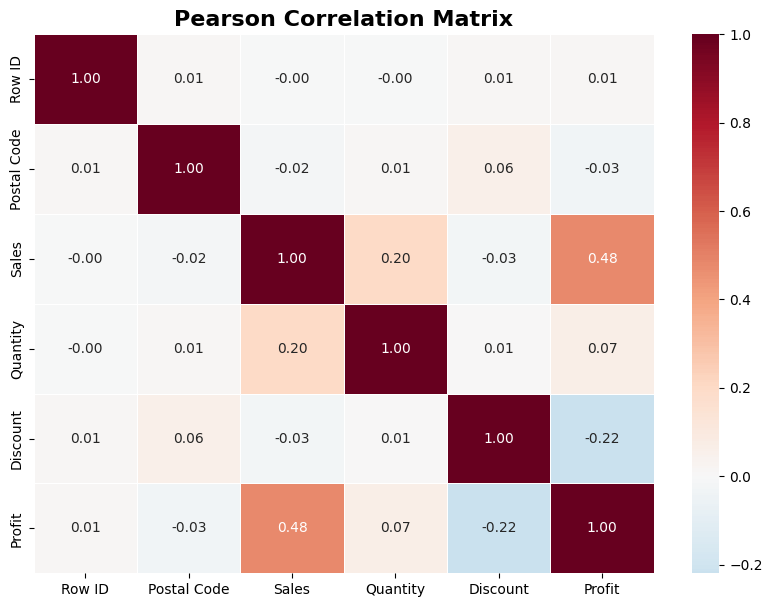

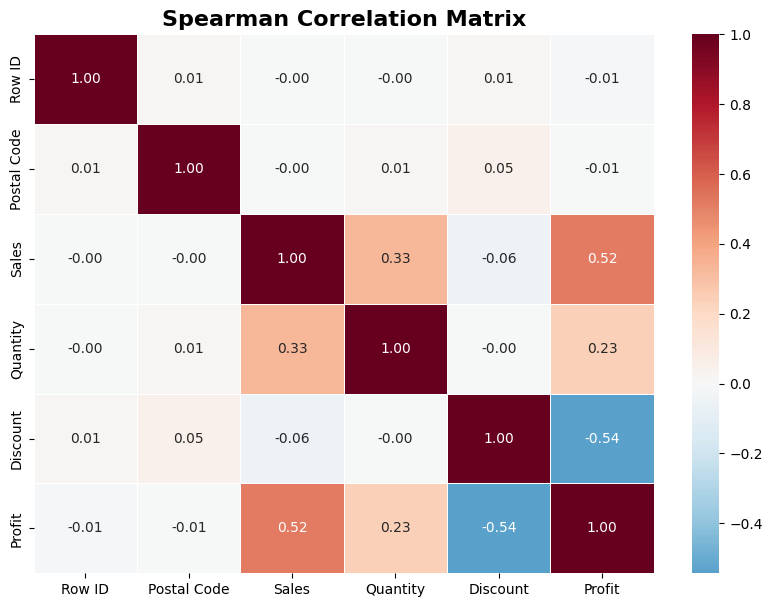


Pair with the biggest disagreement:
Discount and Profit
Pearson: -0.22
Spearman: -0.54


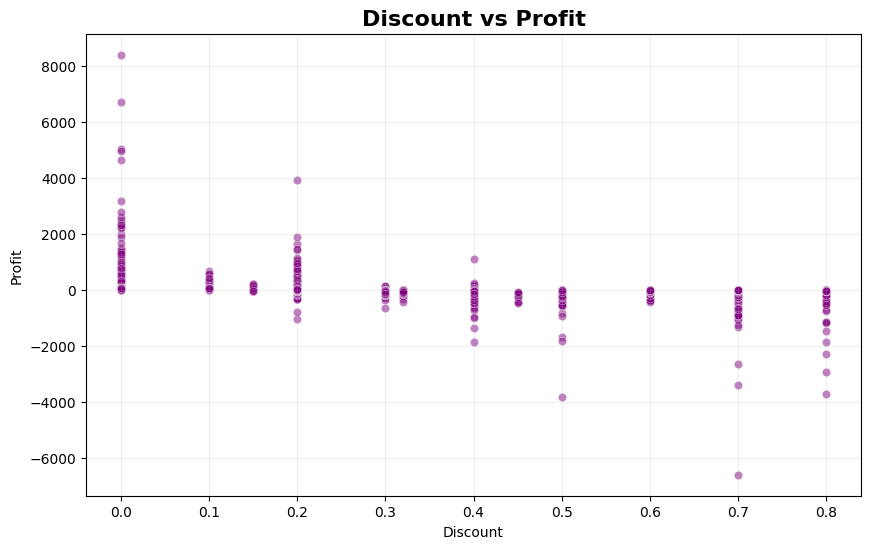

In [8]:
# Select numeric columns
numeric_df = df.select_dtypes(include="number")


# 1. Pearson Correlation
pearson_corr = numeric_df.corr(method="pearson")

print("Pearson Correlation Matrix:")
print(pearson_corr.round(2))


# 2. Spearman Correlation
spearman_corr = numeric_df.corr(method="spearman")

print("\nSpearman Correlation Matrix:")
print(spearman_corr.round(2))


# 3. Pearson Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix", fontsize=16, fontweight="bold")
plt.show()


# 4. Spearman Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix", fontsize=16, fontweight="bold")
plt.show()


# 5. Find the pair with the biggest difference
difference = abs(pearson_corr - spearman_corr)

# Remove diagonal values
for column in difference.columns:
    difference.loc[column, column] = 0

# Find the pair
pair = difference.stack().idxmax()

var1 = pair[0]
var2 = pair[1]

print("\nPair with the biggest disagreement:")
print(var1, "and", var2)

print("Pearson:", round(pearson_corr.loc[var1, var2], 2))
print("Spearman:", round(spearman_corr.loc[var1, var2], 2))


# 6. Scatter Plot of the selected pair
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x=var1,
    y=var2,
    color="purple",
    alpha=0.5
)

plt.title(f"{var1} vs {var2}", fontsize=16, fontweight="bold")
plt.xlabel(var1)
plt.ylabel(var2)
plt.grid(alpha=0.2)

plt.show()

Pearson vs Spearman: Pearson measures linear correlation and is more affected by outliers, while Spearman uses ranks and is more suitable for monotonic relationships. The selected pair shows a noticeable difference between the two methods, which can be explained by outliers or a non-linear relationship visible in the scatter plot.
Correlation does not imply causation. A correlation between two variables does not prove that one variable causes the other.


### Task 5 — Pivot Table + Heatmap

Total Sales by Region and Category:
Category  Furniture  Office Supplies  Technology         All
Region                                                      
Central   163797.16        167026.42   170416.31   501239.89
East      208291.20        205516.06   264973.98   678781.24
South     117298.68        125651.31   148771.91   391721.90
West      252612.74        220853.25   251991.83   725457.82
All       741999.80        719047.03   836154.03  2297200.86


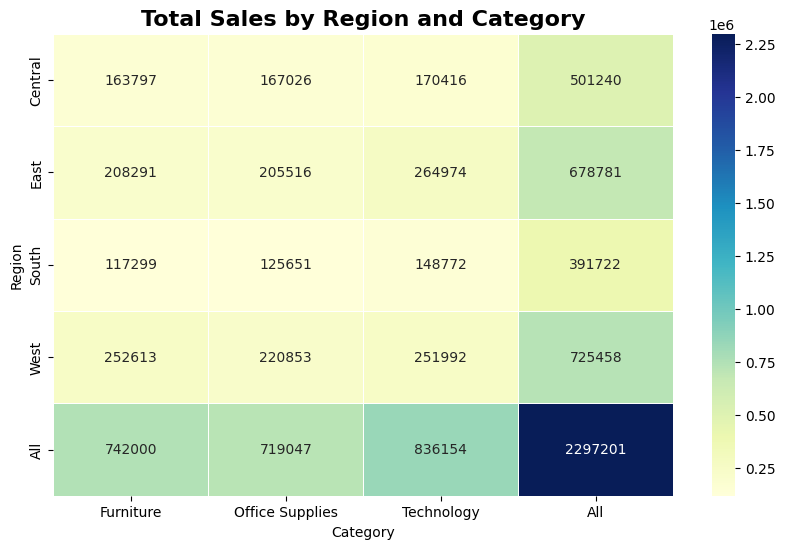


Highest Sales Combination:
Region: East
Category: Technology
Total Sales: 264973.98


In [10]:
# Create pivot table
pivot_table = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum",
    margins=True
)

# Display pivot table
print("Total Sales by Region and Category:")
print(pivot_table.round(2))


# Create heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Total Sales by Region and Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Region")

plt.show()


# Find the highest Region × Category combination
region_category = pivot_table.drop(index="All").drop(columns="All")

max_pair = region_category.stack().idxmax()
max_sales = region_category.stack().max()

print("\nHighest Sales Combination:")
print("Region:", max_pair[0])
print("Category:", max_pair[1])
print("Total Sales:", round(max_sales, 2))

The heatmap shows the total sales across different regions and categories. The highest-selling region-category combination is [Region] and [Category], with total sales of approximately [value].

### Task 6 — Monthly Sales + 3-Month Rolling Average

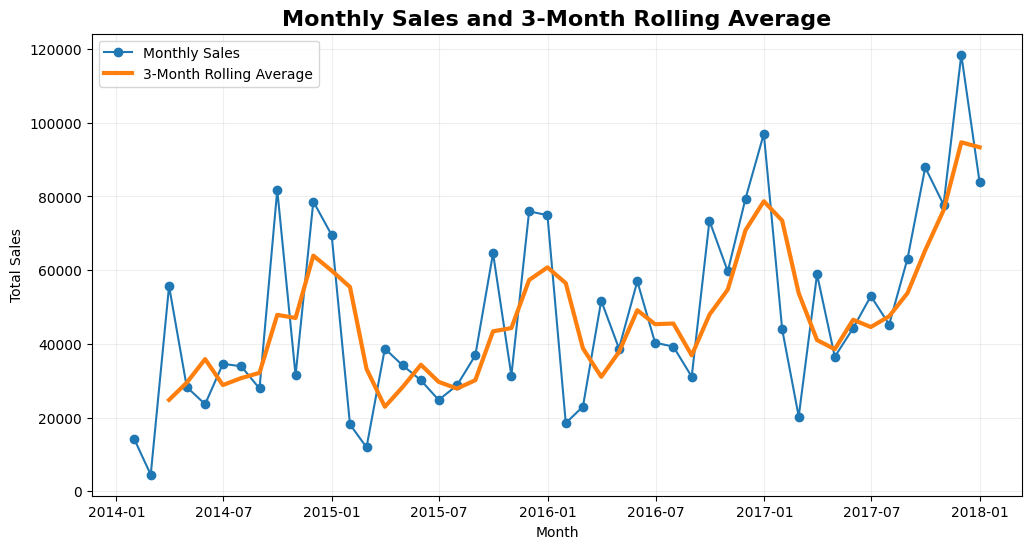

In [11]:
# Convert Order Date into datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])


# Calculate monthly total sales
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)


# Calculate 3-month rolling average
rolling_average = monthly_sales.rolling(window=3).mean()


# Plot monthly sales
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    label="Monthly Sales"
)

plt.plot(
    rolling_average.index,
    rolling_average.values,
    linewidth=3,
    label="3-Month Rolling Average"
)

plt.title(
    "Monthly Sales and 3-Month Rolling Average",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

The monthly sales show fluctuations over time, while the 3-month rolling average provides a smoother view of the overall sales trend. The rolling average helps reduce short-term variations and makes the general trend easier to identify.

### Task 7 — FacetGrid: Discount vs Profit by Region

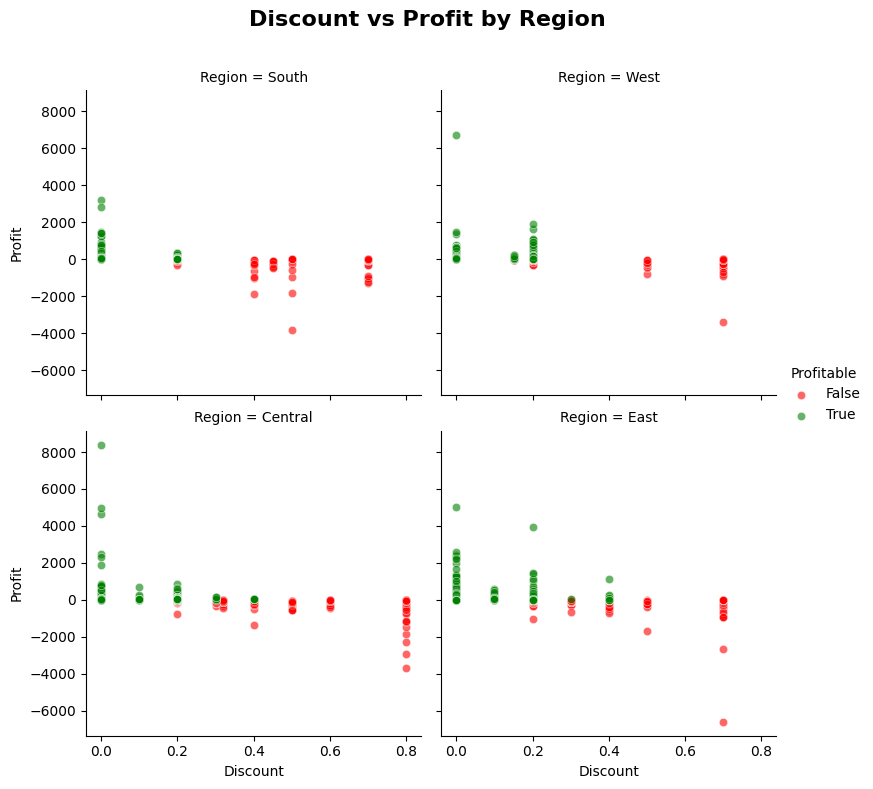

In [13]:
# Create profitable status
df["Profitable"] = df["Profit"] > 0


# Create FacetGrid
g = sns.FacetGrid(
    df,
    col="Region",
    hue="Profitable",
    col_wrap=2,
    height=4,
    palette={True: "green", False: "red"}
)


# Add scatter plot
g.map(
    sns.scatterplot,
    "Discount",
    "Profit",
    alpha=0.6
)


# Add legend
g.add_legend(title="Profitable")


# Add title
g.fig.suptitle(
    "Discount vs Profit by Region",
    fontsize=16,
    fontweight="bold"
)

g.fig.subplots_adjust(top=0.88)

plt.show()

The FacetGrid shows that the relationship between discount and profit varies across regions. Higher discounts are generally associated with more negative profits, and the separate regional plots make it easier to compare this pattern across regions.

### Task 8 — Overplotting + Annotation, Combined

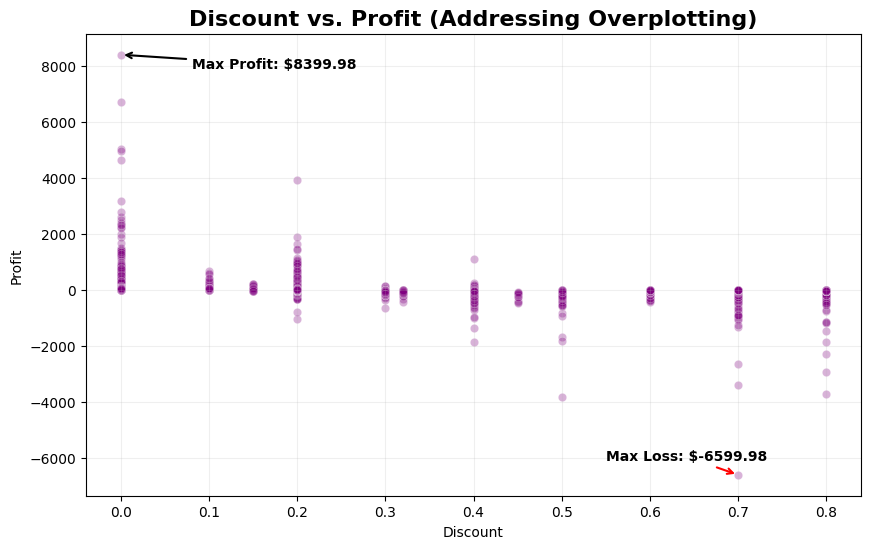

In [14]:
plt.figure(figsize=(10, 6))

# Fixed overplotting using alpha transparency
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.3,
    color="purple"
)

# Identify extreme data points
max_profit = df.loc[df["Profit"].idxmax()]
max_loss = df.loc[df["Profit"].idxmin()]

# Annotate single most profitable order
plt.annotate(
    f"Max Profit: ${max_profit['Profit']:.2f}",
    xy=(max_profit["Discount"], max_profit["Profit"]),
    xytext=(max_profit["Discount"] + 0.08, max_profit["Profit"] - 500),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    fontsize=10,
    fontweight="bold"
)

# Annotate single largest loss order
plt.annotate(
    f"Max Loss: ${max_loss['Profit']:.2f}",
    xy=(max_loss["Discount"], max_loss["Profit"]),
    xytext=(max_loss["Discount"] - 0.15, max_loss["Profit"] + 500),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=10,
    fontweight="bold"
)

plt.title("Discount vs. Profit (Addressing Overplotting)", fontsize=16, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(axis="both", alpha=0.2)

plt.show()

Transparency (alpha=0.3) was chosen over hexbin because the dataset size (~10,000 points) is moderate, and Discount values are discrete fixed steps (e.g., 0.1, 0.2), making hexbin grids visually awkward while transparency clearly reveals dense vertical clusters alongside individual extreme outliers.